# Part 3: Deep Learning and Explainability

This notebook develops a feed-forward neural network to predict hourly traffic volume using the cleaned and feature-engineered dataset produced in Part 2. Model performance is evaluated using mean absolute error (MAE) and the coefficient of determination (R²).

SHAP is applied to a separate, comparable tree-based regression model trained using the same features, target and chronological data split as the neural network. This approach provides an interpretable assessment of how the input features influence predicted traffic demand while avoiding the additional computational complexity of directly explaining the neural network.

The Random Forest used for SHAP is an explanation model developed within this notebook. It is distinct from the tuned Random Forest selected as the final predictive model in the supervised-learning notebook.

In [1]:
import sys
import sklearn

print("Executable:", sys.executable)
print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)

Executable: /usr/local/bin/python3
Python: 3.13.7 (v3.13.7:bcee1c32211, Aug 14 2025, 19:10:51) [Clang 16.0.0 (clang-1600.0.26.6)]
scikit-learn: 1.9.1


In [4]:
from pathlib import Path
import logging
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import tensorflow as tf

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.models import Sequential

np.random.seed(42)
tf.random.set_seed(42)

In [5]:
PROJECT_ROOT = Path.cwd().parent

if not (PROJECT_ROOT / "models").exists():
    PROJECT_ROOT = Path.cwd()

DATA_PATH = (
    PROJECT_ROOT.parent
    / "part2_python"
    / "data"
    / "processed"
    / "traffic_features.csv"
)

MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
LOG_PATH = PROJECT_ROOT / "part3.log"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

LOGGER = logging.getLogger(__name__)

if not LOGGER.handlers:
    LOGGER.setLevel(logging.INFO)

    formatter = logging.Formatter(
        "%(asctime)s | %(levelname)s | %(name)s | %(message)s"
    )

    console_handler = logging.StreamHandler(sys.stdout)
    console_handler.setFormatter(formatter)

    file_handler = logging.FileHandler(
        LOG_PATH,
        mode="a",
        encoding="utf-8",
    )
    file_handler.setFormatter(formatter)

    LOGGER.addHandler(console_handler)
    LOGGER.addHandler(file_handler)

LOGGER.info("Deep-learning and explainability notebook started")

2026-09-25 03:18:54,568 | INFO | __main__ | Deep-learning and explainability notebook started


## Data preparation

The feature-engineered dataset is ordered chronologically before splitting. The earliest 80% of observations are used for model development, while the latest 20% are retained for testing. This provides a more realistic evaluation of future traffic predictions than randomly mixing earlier and later observations.

The input variables include time, calendar and weather features. Traffic volume is the regression target and is therefore excluded from the predictors to prevent target leakage.

In [6]:
try:
    data = pd.read_csv(DATA_PATH)
except FileNotFoundError as exc:
    LOGGER.error("Feature dataset not found at %s", DATA_PATH)
    raise FileNotFoundError(
        f"Feature dataset not found at {DATA_PATH}. "
        "Run the Part 2 pipeline first."
    ) from exc

data["date_time"] = pd.to_datetime(
    data["date_time"],
    errors="coerce",
)

invalid_dates = data["date_time"].isna().sum()

if invalid_dates > 0:
    LOGGER.warning(
        "Dropping %d records with invalid dates",
        invalid_dates,
    )
    data = data.dropna(subset=["date_time"]).copy()

data = data.sort_values("date_time").reset_index(drop=True)

data["day_of_week_sin"] = np.sin(
    2 * np.pi * data["day_of_week"] / 7
)
data["day_of_week_cos"] = np.cos(
    2 * np.pi * data["day_of_week"] / 7
)

weather_features = sorted(
    column
    for column in data.columns
    if column.startswith("weather_main_")
)

model_features = [
    "temp",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "is_holiday",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "month_sin",
    "month_cos",
] + weather_features

X = data[model_features].copy()
y = data["traffic_volume"].copy()

split_index = int(len(data) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

LOGGER.info(
    "Prepared chronological split with %d training and %d test records",
    len(X_train),
    len(X_test),
)

print("Number of features:", len(model_features))
print("Training records:", len(X_train))
print("Test records:", len(X_test))
print(
    "Training period:",
    data.loc[: split_index - 1, "date_time"].min(),
    "to",
    data.loc[: split_index - 1, "date_time"].max(),
)
print(
    "Test period:",
    data.loc[split_index:, "date_time"].min(),
    "to",
    data.loc[split_index:, "date_time"].max(),
)

2026-09-25 03:20:24,024 | INFO | __main__ | Prepared chronological split with 38549 training and 9638 test records
Number of features: 23
Training records: 38549
Test records: 9638
Training period: 2012-10-02 09:00:00 to 2017-11-01 19:00:00
Test period: 2017-11-01 20:00:00 to 2018-09-30 23:00:00


## Neural network for traffic-demand prediction

A feed-forward neural network is trained to predict hourly traffic volume. The network contains two hidden layers with ReLU activation and dropout regularisation. ReLU enables the model to learn non-linear relationships, while dropout reduces the risk of overfitting by randomly deactivating a proportion of neurons during training.

Both the input features and target values are standardised to improve numerical stability and support efficient neural-network training. Early stopping monitors validation loss and restores the model weights from the best-performing epoch. This prevents unnecessary training once validation performance stops improving.

In [7]:
y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(
    y_train.to_numpy().reshape(-1, 1)
).ravel()

neural_network = Sequential(
    [
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(64, activation="relu"),
        Dropout(0.20),
        Dense(32, activation="relu"),
        Dropout(0.10),
        Dense(1),
    ]
)

neural_network.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mean_squared_error",
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

LOGGER.info("Training neural network for traffic prediction")

history = neural_network.fit(
    X_train_scaled,
    y_train_scaled,
    validation_split=0.20,
    epochs=50,
    batch_size=256,
    callbacks=[early_stopping],
    shuffle=False,
    verbose=1,
)

LOGGER.info(
    "Neural-network training completed after %d epochs",
    len(history.history["loss"]),
)

print(
    "Training epochs completed:",
    len(history.history["loss"]),
)

2026-09-25 03:21:00,661 | INFO | __main__ | Training neural network for traffic prediction
Epoch 1/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6649 - val_loss: 0.4661
Epoch 2/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3822 - val_loss: 0.3248
Epoch 3/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 990us/step - loss: 0.3076 - val_loss: 0.2732
Epoch 4/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2633 - val_loss: 0.2066
Epoch 5/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2285 - val_loss: 0.1918
Epoch 6/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1993 - val_loss: 0.1655
Epoch 7/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1803 - val_loss: 0.1604
Epoch 8/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1634 - val_loss: 0.1333
Epoch 9/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1496 - val_loss: 0.1313
Epoch 10/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 981us/step - loss: 0.1396 - val_loss: 0.1147
Epoch 11/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [8]:
test_predictions_scaled = neural_network.predict(
    X_test_scaled,
    verbose=0,
)

test_predictions = y_scaler.inverse_transform(
    test_predictions_scaled
).ravel()

nn_mae = mean_absolute_error(
    y_test,
    test_predictions,
)

nn_r2 = r2_score(
    y_test,
    test_predictions,
)

neural_network_results = pd.DataFrame(
    {
        "Model": ["Neural Network"],
        "MAE": [nn_mae],
        "R2": [nn_r2],
        "Training_Epochs": [
            len(history.history["loss"])
        ],
    }
)

LOGGER.info(
    "Neural network evaluated with MAE %.2f and R2 %.4f",
    nn_mae,
    nn_r2,
)

neural_network_results.round(4)

2026-09-25 03:21:42,746 | INFO | __main__ | Neural network evaluated with MAE 493.06 and R2 0.8845


,Model,MAE,R2,Training_Epochs
0,Neural Network,493.0636,0.8845,26


### Neural-network performance

The neural network achieved a mean absolute error of approximately 493 vehicles per hour and an R² value of 0.8845 on the chronologically held-out test data. This means that the model explained approximately 88.45% of the variation in traffic volume, while its predictions differed from the observed traffic volume by approximately 493 vehicles per hour on average.

Training stopped after 26 epochs because early stopping detected that validation performance was no longer improving. The training and validation loss curves remained close and levelled off at similar values, providing no clear indication of substantial overfitting. The results show that the neural network learned meaningful relationships between the time, calendar and weather features and hourly traffic demand.

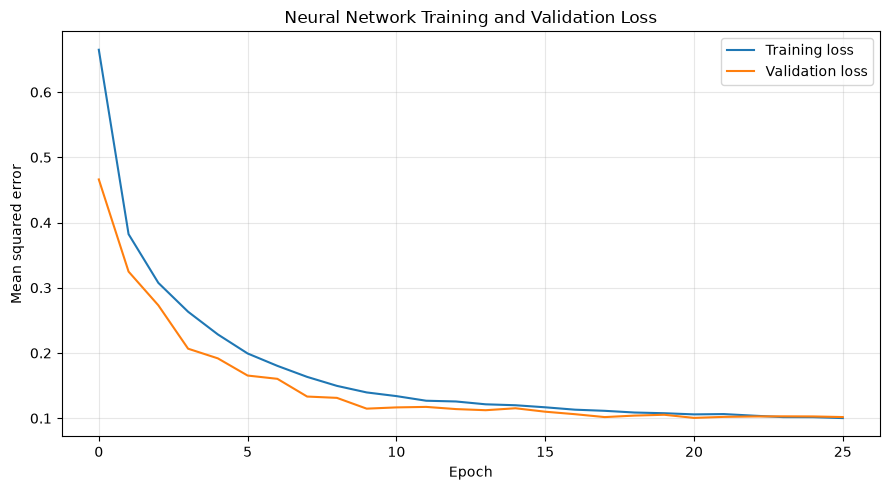

2026-09-25 03:22:39,136 | INFO | __main__ | Saved neural-network loss figure to /Users/misatoniwa/Downloads/smart-city-traffic-capstone/part3_machine_learning/reports/neural_network_training_loss.png


In [9]:
loss_figure_path = (
    REPORTS_DIR / "neural_network_training_loss.png"
)

plt.figure(figsize=(9, 5))

plt.plot(
    history.history["loss"],
    label="Training loss",
)

plt.plot(
    history.history["val_loss"],
    label="Validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("Mean squared error")
plt.title("Neural Network Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    loss_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

LOGGER.info(
    "Saved neural-network loss figure to %s",
    loss_figure_path,
)

In [10]:
neural_network_path = (
    MODELS_DIR / "traffic_neural_network.keras"
)

x_scaler_path = (
    MODELS_DIR / "neural_network_x_scaler.joblib"
)

y_scaler_path = (
    MODELS_DIR / "neural_network_y_scaler.joblib"
)

results_path = (
    REPORTS_DIR / "neural_network_results.csv"
)

neural_network.save(neural_network_path)
joblib.dump(scaler, x_scaler_path)
joblib.dump(y_scaler, y_scaler_path)

neural_network_results.to_csv(
    results_path,
    index=False,
)

print(f"Saved neural network: {neural_network_path}")
print(f"Saved input scaler: {x_scaler_path}")
print(f"Saved target scaler: {y_scaler_path}")
print(f"Saved results: {results_path}")

LOGGER.info(
    "Saved neural network and preprocessing objects"
)

Saved neural network: /Users/misatoniwa/Downloads/smart-city-traffic-capstone/part3_machine_learning/models/traffic_neural_network.keras
Saved input scaler: /Users/misatoniwa/Downloads/smart-city-traffic-capstone/part3_machine_learning/models/neural_network_x_scaler.joblib
Saved target scaler: /Users/misatoniwa/Downloads/smart-city-traffic-capstone/part3_machine_learning/models/neural_network_y_scaler.joblib
Saved results: /Users/misatoniwa/Downloads/smart-city-traffic-capstone/part3_machine_learning/reports/neural_network_results.csv
2026-09-25 03:22:56,510 | INFO | __main__ | Saved neural network and preprocessing objects


## SHAP explainability analysis

SHAP is used to examine which features influence predicted traffic volume and the direction of their effects. A separate Random Forest regressor is trained using the same features, target and chronological data split as the neural network, allowing its performance to be compared on the same prediction problem.

A tree-based model is used because TreeSHAP provides an efficient and reliable method for calculating feature contributions. The Random Forest is evaluated on the held-out test period before its explanations are interpreted. SHAP values are calculated for 1,000 test observations to provide a representative explanation while keeping the computational requirements manageable.

The resulting SHAP values explain the predictions of this separate Random Forest model. They do not directly explain the neural network or the tuned Random Forest developed in the supervised-learning notebook.

In [11]:
shap_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=18,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

LOGGER.info(
    "Training comparable Random Forest model for SHAP"
)

shap_model.fit(
    X_train,
    y_train,
)

shap_model_predictions = shap_model.predict(
    X_test
)

shap_model_mae = mean_absolute_error(
    y_test,
    shap_model_predictions,
)

shap_model_r2 = r2_score(
    y_test,
    shap_model_predictions,
)

shap_model_results = pd.DataFrame(
    {
        "Model": ["Random Forest for SHAP"],
        "MAE": [shap_model_mae],
        "R2": [shap_model_r2],
    }
)

LOGGER.info(
    "SHAP model evaluated with MAE %.2f and R2 %.4f",
    shap_model_mae,
    shap_model_r2,
)

shap_model_results.round(4)

2026-09-25 03:23:35,892 | INFO | __main__ | Training comparable Random Forest model for SHAP
2026-09-25 03:23:38,090 | INFO | __main__ | SHAP model evaluated with MAE 295.55 and R2 0.9277


,Model,MAE,R2
0,Random Forest for SHAP,295.5493,0.9277


### Comparable model performance

The Random Forest trained for the SHAP analysis achieved a mean absolute error of approximately 296 vehicles per hour and an R² value of 0.9277 on the same chronologically held-out test period. It therefore performed better than the neural network evaluated in this notebook.

Its strong predictive performance indicates that it captured substantial relationships within the prediction problem and supports its use as a comparable explanation model. However, it was trained specifically for the SHAP analysis and is separate from the tuned Random Forest selected as the final predictive model in the supervised-learning notebook.

2026-09-25 03:24:32,657 | INFO | __main__ | Calculating SHAP values for 1000 test observations


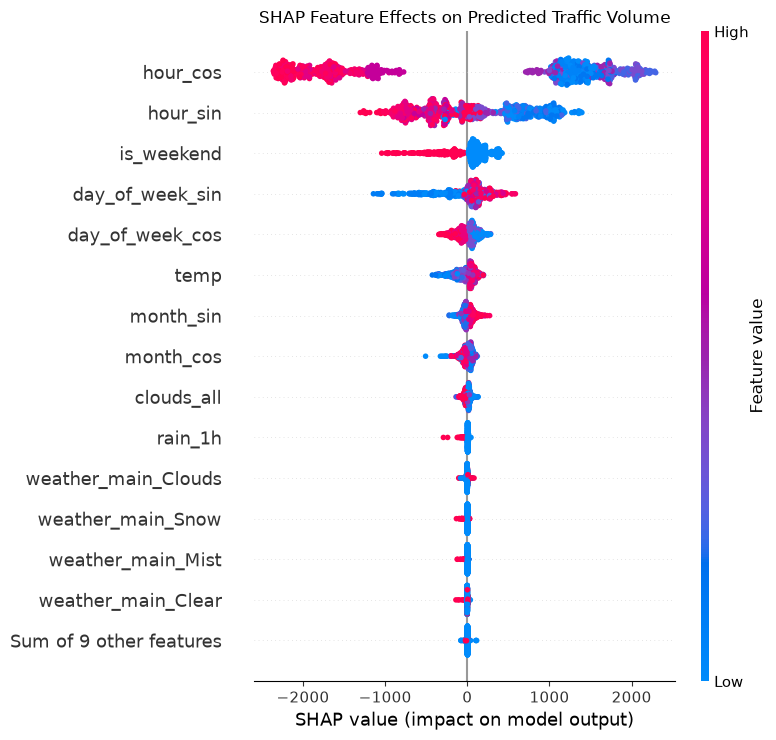

2026-09-25 03:28:05,669 | INFO | __main__ | Saved SHAP summary figure to /Users/misatoniwa/Downloads/smart-city-traffic-capstone/part3_machine_learning/reports/shap_feature_summary.png


In [12]:
shap_sample = X_test.sample(
    n=min(1000, len(X_test)),
    random_state=42,
)

LOGGER.info(
    "Calculating SHAP values for %d test observations",
    len(shap_sample),
)

explainer = shap.TreeExplainer(
    shap_model
)

shap_values = explainer(
    shap_sample,
    check_additivity=False,
)

shap_figure_path = (
    REPORTS_DIR / "shap_feature_summary.png"
)

shap.plots.beeswarm(
    shap_values,
    max_display=15,
    show=False,
)

plt.title(
    "SHAP Feature Effects on Predicted Traffic Volume"
)

plt.tight_layout()

plt.savefig(
    shap_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

LOGGER.info(
    "Saved SHAP summary figure to %s",
    shap_figure_path,
)

### SHAP interpretation

The SHAP analysis indicates that time-related variables were the strongest drivers of the Random Forest traffic predictions. The cyclical hour variables, `hour_cos` and `hour_sin`, had the largest mean absolute SHAP values. These variables should be interpreted together because they jointly encode position within the same 24-hour cycle rather than representing two independent effects.

Weekend status was also influential. High values of `is_weekend`, representing weekend observations, were generally associated with negative SHAP values and therefore with reductions in predicted traffic volume. The cyclical day-of-week variables also contributed to the predictions, although their overall effects were smaller than those of the hour variables.

Temperature, rainfall, cloud cover and the individual weather categories had substantially smaller overall effects than the principal time-related variables. This provides model-based evidence that recurring hourly and weekly travel patterns were stronger predictors of traffic demand than weather conditions alone within this dataset.

SHAP values describe how features contributed to the predictions of the separate Random Forest explanation model. They do not directly explain the neural network and should not be interpreted as evidence of causal relationships.

In [13]:
mean_absolute_shap = np.abs(
    shap_values.values
).mean(axis=0)

shap_importance = pd.DataFrame(
    {
        "Feature": shap_sample.columns,
        "Mean_Absolute_SHAP": mean_absolute_shap,
    }
).sort_values(
    "Mean_Absolute_SHAP",
    ascending=False,
).reset_index(drop=True)

model_comparison = pd.DataFrame(
    {
        "Model": [
            "Neural Network",
            "Random Forest for SHAP",
        ],
        "MAE": [
            nn_mae,
            shap_model_mae,
        ],
        "R2": [
            nn_r2,
            shap_model_r2,
        ],
    }
)

shap_model_path = (
    MODELS_DIR / "shap_random_forest.joblib"
)

shap_importance_path = (
    REPORTS_DIR / "shap_feature_importance.csv"
)

comparison_path = (
    REPORTS_DIR / "deep_learning_model_comparison.csv"
)

joblib.dump(
    shap_model,
    shap_model_path,
    compress=3,
)

shap_importance.to_csv(
    shap_importance_path,
    index=False,
)

model_comparison.to_csv(
    comparison_path,
    index=False,
)

print(f"Saved SHAP model: {shap_model_path}")
print(f"Saved SHAP importance: {shap_importance_path}")
print(f"Saved model comparison: {comparison_path}")

LOGGER.info(
    "Saved SHAP model, feature importance and model comparison"
)

display(model_comparison.round(4))
display(shap_importance.head(10).round(2))

Saved SHAP model: /Users/misatoniwa/Downloads/smart-city-traffic-capstone/part3_machine_learning/models/shap_random_forest.joblib
Saved SHAP importance: /Users/misatoniwa/Downloads/smart-city-traffic-capstone/part3_machine_learning/reports/shap_feature_importance.csv
Saved model comparison: /Users/misatoniwa/Downloads/smart-city-traffic-capstone/part3_machine_learning/reports/deep_learning_model_comparison.csv
2026-09-25 03:29:38,086 | INFO | __main__ | Saved SHAP model, feature importance and model comparison


,Model,MAE,R2
0,Neural Network,493.0636,0.8845
1,Random Forest for SHAP,295.5493,0.9277


,Feature,Mean_Absolute_SHAP
0,hour_cos,1586.69
1,hour_sin,546.47
2,is_weekend,197.78
3,day_of_week_sin,191.99
4,day_of_week_cos,93.97
5,temp,86.48
6,month_sin,50.62
7,month_cos,44.03
8,clouds_all,26.32
9,rain_1h,9.19


## Conclusion

The neural network successfully predicted hourly traffic demand over a chronologically held-out test period, achieving a mean absolute error of approximately 493 vehicles per hour and an R² value of 0.8845. This means that it explained approximately 88.45% of the variation in traffic volume.

The separate Random Forest model trained for SHAP analysis performed better, with a mean absolute error of approximately 296 vehicles per hour and an R² value of 0.9277. SHAP analysis identified the cyclical hour variables as the strongest contributors to its predictions, followed by weekend status and day-of-week patterns. Temperature, cloud cover, rainfall, and individual weather categories had smaller overall effects.

These findings indicate that recurring hourly and weekly travel patterns were stronger predictive signals than weather conditions alone. Traffic-management resources could therefore be scheduled primarily around established daily and weekly demand patterns, with weather information used as a supporting signal. However, the SHAP results explain the separate Random Forest model used in this notebook and should not be interpreted as direct explanations of the neural network or proof of causal relationships.

Across the project, the tuned Random Forest developed in the supervised-learning notebook remains the preferred final predictive model because it achieved the strongest test performance.